In [6]:
# 2.2 从零实现单隐藏层 MLP，不使用高级 API
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 设置随机种子，保证可复现
torch.manual_seed(42)

# 1. 加载 Fashion-MNIST 数据集
transform = transforms.ToTensor()
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 256
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

# 2. 初始化模型参数
# 输入层：28*28=784，隐藏层：256，输出层：10
input_size = 784
hidden_size = 256
output_size = 10

# 正态分布初始化，标准差 0.01
W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

# 启用梯度追踪
params = [W1, b1, W2, b2]
for p in params:
    p.requires_grad_(True)

# 3. 实现 ReLU 激活函数
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

# 4. 实现带有 Softmax 的交叉熵损失函数
def softmax_cross_entropy(logits, y):
    # logits: (batch_size, num_classes), y: (batch_size) 真实标签
    # 数值稳定 softmax
    logits_max = torch.max(logits, dim=1, keepdim=True)[0]
    exp_logits = torch.exp(logits - logits_max)
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    # 交叉熵
    batch_size = logits.shape[0]
    loss = -torch.log(probs[range(batch_size), y] + 1e-8).mean()
    return loss

# 5. 训练循环（小批量 SGD 手动更新）
def train_epoch(loader, W1, b1, W2, b2, lr=0.1):
    total_loss = 0
    for X, y in loader:
        # 展平图像
        X = X.view(X.shape[0], -1)
        # 前向传播
        h = relu(X @ W1 + b1)
        o = h @ W2 + b2
        loss = softmax_cross_entropy(o, y)
        total_loss += loss.item()
        # 反向传播（自动求导）
        loss.backward()
        # 手动更新参数（无权重衰减）
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
            # 清零梯度
            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()
    return total_loss / len(loader)

def evaluate(loader, W1, b1, W2, b2):
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in loader:
            X = X.view(X.shape[0], -1)
            h = relu(X @ W1 + b1)
            o = h @ W2 + b2
            pred = torch.argmax(o, dim=1)
            correct += (pred == y).sum().item()
            total += y.shape[0]
    return correct / total

# 训练 10 个 epoch
epochs = 10
for epoch in range(epochs):
    loss = train_epoch(train_loader, W1, b1, W2, b2, lr=0.1)
    train_acc = evaluate(train_loader, W1, b1, W2, b2)
    test_acc = evaluate(test_loader, W1, b1, W2, b2)
    print(f"Epoch {epoch+1:2d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

print("2.2 完成：单隐藏层 MLP 从零实现，使用手动 SGD 训练。")


100%|██████████| 26.4M/26.4M [00:09<00:00, 2.93MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 55.1kB/s]
100%|██████████| 4.42M/4.42M [02:46<00:00, 26.6kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.13MB/s]


Epoch  1, Loss: 1.0444, Train Acc: 0.7341, Test Acc: 0.7244
Epoch  2, Loss: 0.6010, Train Acc: 0.8078, Test Acc: 0.7974
Epoch  3, Loss: 0.5192, Train Acc: 0.8334, Test Acc: 0.8195
Epoch  4, Loss: 0.4825, Train Acc: 0.8171, Test Acc: 0.8061
Epoch  5, Loss: 0.4561, Train Acc: 0.8325, Test Acc: 0.8162
Epoch  6, Loss: 0.4374, Train Acc: 0.8536, Test Acc: 0.8388
Epoch  7, Loss: 0.4214, Train Acc: 0.8532, Test Acc: 0.8412
Epoch  8, Loss: 0.4067, Train Acc: 0.8494, Test Acc: 0.8328
Epoch  9, Loss: 0.3925, Train Acc: 0.8673, Test Acc: 0.8500
Epoch 10, Loss: 0.3843, Train Acc: 0.8651, Test Acc: 0.8489
2.2 完成：单隐藏层 MLP 从零实现，使用手动 SGD 训练。


=== 实验1: 无正则化 ===
Epoch 10, Train Loss: 2.1981, Test Loss: 2.1934
Epoch 20, Train Loss: 1.9939, Test Loss: 1.9898
Epoch 30, Train Loss: 1.7071, Test Loss: 1.7030
Epoch 40, Train Loss: 1.4499, Test Loss: 1.4523
Epoch 50, Train Loss: 1.2615, Test Loss: 1.2760

=== 实验2: 权重衰减 (λ=0.001) ===
Epoch 10, Train Loss: 2.1894, Test Loss: 2.1840
Epoch 20, Train Loss: 1.9746, Test Loss: 1.9684
Epoch 30, Train Loss: 1.6803, Test Loss: 1.6768
Epoch 40, Train Loss: 1.4282, Test Loss: 1.4357
Epoch 50, Train Loss: 1.2506, Test Loss: 1.2664

=== 实验3: Dropout (p=0.5) ===
Epoch 10, Train Loss: 2.1897, Test Loss: 2.1875
Epoch 20, Train Loss: 1.9882, Test Loss: 1.9772
Epoch 30, Train Loss: 1.7022, Test Loss: 1.6927
Epoch 40, Train Loss: 1.4618, Test Loss: 1.4549
Epoch 50, Train Loss: 1.2898, Test Loss: 1.2887


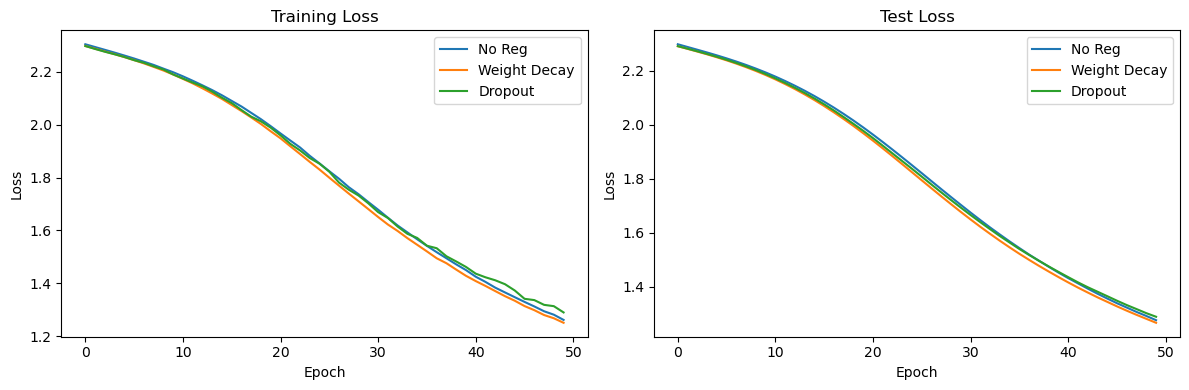

3.2 完成：对比了无正则化、权重衰减、Dropout 的训练和验证误差曲线。


In [7]:
# 3.2 在 MLP 上加入权重衰减（L2）和 Dropout，对比三种情况
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 为了制造过拟合，使用少量样本训练复杂模型（隐藏层扩大）
torch.manual_seed(42)

transform = transforms.ToTensor()
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 只取前 500 个样本作为训练集（少量数据加剧过拟合）
small_train_set = torch.utils.data.Subset(train_set, range(500))
train_loader_small = torch.utils.data.DataLoader(small_train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

input_size = 784
hidden_size = 512   # 大隐藏层，容易过拟合
output_size = 10

# 定义 Dropout 函数（训练时随机丢弃，测试时缩放）
def dropout_layer(x, dropout_prob, is_training=True):
    if not is_training or dropout_prob == 0:
        return x
    mask = (torch.rand(x.shape) > dropout_prob).float()
    return x * mask / (1 - dropout_prob)   # 缩放保持期望不变

# 定义模型封装（每次前向传播需手动计算）
class SimpleMLP:
    def __init__(self, W1, b1, W2, b2):
        self.W1 = W1
        self.b1 = b1
        self.W2 = W2
        self.b2 = b2
        self.is_training = True
        self.dropout_prob = 0.0

    def forward(self, X):
        h = X @ self.W1 + self.b1
        h = torch.maximum(h, torch.tensor(0.0))  # ReLU
        h = dropout_layer(h, self.dropout_prob, self.is_training)
        o = h @ self.W2 + self.b2
        return o

def softmax_cross_entropy(logits, y):
    logits_max = torch.max(logits, dim=1, keepdim=True)[0]
    exp_logits = torch.exp(logits - logits_max)
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    batch_size = logits.shape[0]
    loss = -torch.log(probs[range(batch_size), y] + 1e-8).mean()
    return loss

def train_model(model, train_loader, test_loader, lr=0.01, weight_decay=0.0, dropout_prob=0.0, epochs=50):
    model.is_training = True
    model.dropout_prob = dropout_prob
    # 参数列表
    params = [model.W1, model.b1, model.W2, model.b2]
    for p in params:
        p.requires_grad_(True)
    train_losses = []
    test_losses = []
    for epoch in range(epochs):
        total_loss = 0
        for X, y in train_loader:
            X = X.view(X.shape[0], -1)
            logits = model.forward(X)
            loss = softmax_cross_entropy(logits, y)
            total_loss += loss.item()
            loss.backward()
            with torch.no_grad():
                # 权重衰减（L2）: w = w - lr * (grad + lambda * w)
                for p, wd in zip(params, [weight_decay, 0, weight_decay, 0]):  # 偏置通常不衰减
                    if wd != 0:
                        p.grad += wd * p   # 添加 L2 梯度贡献
                # 更新
                model.W1 -= lr * model.W1.grad
                model.b1 -= lr * model.b1.grad
                model.W2 -= lr * model.W2.grad
                model.b2 -= lr * model.b2.grad
                # 清零
                model.W1.grad.zero_()
                model.b1.grad.zero_()
                model.W2.grad.zero_()
                model.b2.grad.zero_()
        train_losses.append(total_loss / len(train_loader))
        # 测试损失（不启用 dropout）
        model.is_training = False
        test_loss = 0
        with torch.no_grad():
            for X, y in test_loader:
                X = X.view(X.shape[0], -1)
                logits = model.forward(X)
                loss = softmax_cross_entropy(logits, y)
                test_loss += loss.item()
        test_losses.append(test_loss / len(test_loader))
        model.is_training = True
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}")
    return train_losses, test_losses

# 初始化参数（三种实验共用）
def init_params():
    W1 = torch.randn(input_size, hidden_size) * 0.01
    b1 = torch.zeros(hidden_size)
    W2 = torch.randn(hidden_size, output_size) * 0.01
    b2 = torch.zeros(output_size)
    return W1, b1, W2, b2

# 实验1：无正则化
print("=== 实验1: 无正则化 ===")
W1, b1, W2, b2 = init_params()
model1 = SimpleMLP(W1, b1, W2, b2)
train_loss1, test_loss1 = train_model(model1, train_loader_small, test_loader, lr=0.01, weight_decay=0.0, dropout_prob=0.0, epochs=50)

# 实验2：权重衰减（L2）
print("\n=== 实验2: 权重衰减 (λ=0.001) ===")
W1, b1, W2, b2 = init_params()
model2 = SimpleMLP(W1, b1, W2, b2)
train_loss2, test_loss2 = train_model(model2, train_loader_small, test_loader, lr=0.01, weight_decay=0.001, dropout_prob=0.0, epochs=50)

# 实验3：Dropout (p=0.5)
print("\n=== 实验3: Dropout (p=0.5) ===")
W1, b1, W2, b2 = init_params()
model3 = SimpleMLP(W1, b1, W2, b2)
train_loss3, test_loss3 = train_model(model3, train_loader_small, test_loader, lr=0.01, weight_decay=0.0, dropout_prob=0.5, epochs=50)

# 绘制对比曲线
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_loss1, label='No Reg')
plt.plot(train_loss2, label='Weight Decay')
plt.plot(train_loss3, label='Dropout')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(test_loss1, label='No Reg')
plt.plot(test_loss2, label='Weight Decay')
plt.plot(test_loss3, label='Dropout')
plt.title('Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()
print("3.2 完成：对比了无正则化、权重衰减、Dropout 的训练和验证误差曲线。")

=== 实验1: Sigmoid + 普通高斯初始化 (std=1) ===
梯度范数范围: min=7.74e+03, max=1.61e+05, 后几层明显小于前几层 -> 梯度消失

=== 实验2: ReLU + 大标准差初始化 (std=10) ===
梯度范数: min=nan, max=nan
输出出现 NaN/Inf，梯度爆炸

=== 实验3: Xavier 初始化 + ReLU ===
梯度范数范围: min=6.0482, max=32.4293 稳定在合理区间


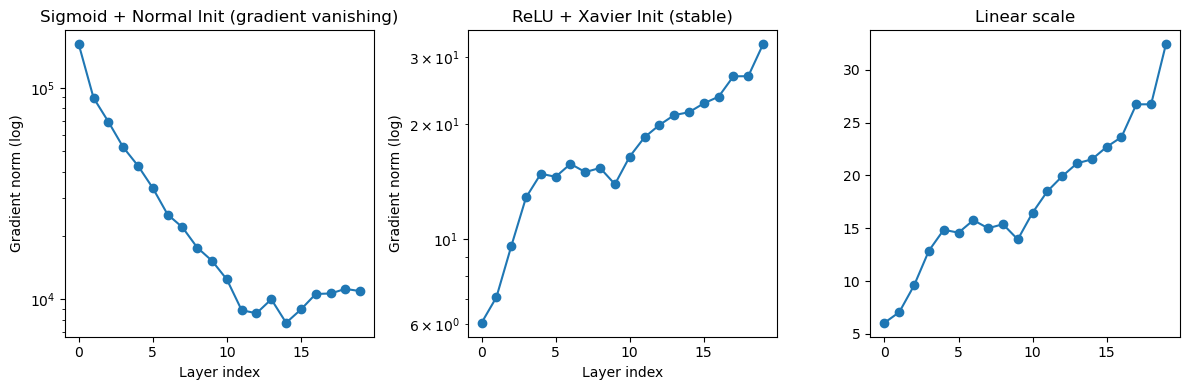

4.2 完成：验证了梯度消失/爆炸现象，以及 Xavier 初始化的稳定性。


In [8]:
# 4.2 构建深层网络，模拟梯度不稳定，验证 Xavier 初始化
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. 构建20层深层全连接网络，宽度256
class DeepNet(nn.Module):
    def __init__(self, activation=nn.Sigmoid, init_method='normal'):
        super().__init__()
        layers = []
        self.activation = activation()
        # 输入784，之后每层256，共20层
        in_dim = 784
        for i in range(20):
            linear = nn.Linear(in_dim, 256)
            if init_method == 'normal':
                nn.init.normal_(linear.weight, mean=0, std=1)
            elif init_method == 'xavier':
                nn.init.xavier_uniform_(linear.weight)
            nn.init.zeros_(linear.bias)
            layers.append(linear)
            # 最后一层后不加激活（为了打印梯度，但实际加也可以）
            if i < 19:
                layers.append(self.activation)
            in_dim = 256
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# 辅助函数：计算每层参数的梯度范数
def compute_grad_norms(model):
    norms = []
    for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name:
            norms.append(param.grad.norm().item())
    return norms

# 输入随机数据
batch_size = 64
input_data = torch.randn(batch_size, 784)

# 2. Sigmoid + 普通高斯初始化（标准差1） -> 梯度消失
print("=== 实验1: Sigmoid + 普通高斯初始化 (std=1) ===")
model1 = DeepNet(activation=nn.Sigmoid, init_method='normal')
output = model1(input_data)
# 模拟一次反向传播（计算一个虚拟损失，比如输出求和）
loss = output.sum()
loss.backward()
norms1 = compute_grad_norms(model1)
print(f"梯度范数范围: min={min(norms1):.2e}, max={max(norms1):.2e}, 后几层明显小于前几层 -> 梯度消失")
# 可视化梯度分布
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(norms1, marker='o')
plt.yscale('log')
plt.title('Sigmoid + Normal Init (gradient vanishing)')
plt.xlabel('Layer index')
plt.ylabel('Gradient norm (log)')

# 3. ReLU + 大标准差初始化 (std=10) -> 梯度爆炸或NaN
print("\n=== 实验2: ReLU + 大标准差初始化 (std=10) ===")
class DeepNetReLU(nn.Module):
    def __init__(self, std=10):
        super().__init__()
        layers = []
        in_dim = 784
        for i in range(20):
            linear = nn.Linear(in_dim, 256)
            nn.init.normal_(linear.weight, mean=0, std=std)
            nn.init.zeros_(linear.bias)
            layers.append(linear)
            if i < 19:
                layers.append(nn.ReLU())
            in_dim = 256
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

model2 = DeepNetReLU(std=10)
try:
    output2 = model2(input_data)
    loss2 = output2.sum()
    loss2.backward()
    norms2 = compute_grad_norms(model2)
    print(f"梯度范数: min={min(norms2):.2e}, max={max(norms2):.2e}")
    if torch.isnan(output2).any() or torch.isinf(output2).any():
        print("输出出现 NaN/Inf，梯度爆炸")
    else:
        print("未出现NaN但梯度很大，可能接近爆炸")
except Exception as e:
    print(f"发生数值溢出: {e}")
# 为了避免程序崩溃，这里不画图，直接跳到下一个实验

# 4. Xavier 初始化 + ReLU（稳定）
print("\n=== 实验3: Xavier 初始化 + ReLU ===")
model3 = DeepNet(activation=nn.ReLU, init_method='xavier')
output3 = model3(input_data)
loss3 = output3.sum()
loss3.backward()
norms3 = compute_grad_norms(model3)
print(f"梯度范数范围: min={min(norms3):.4f}, max={max(norms3):.4f} 稳定在合理区间")

plt.subplot(1,3,2)
plt.plot(norms3, marker='o')
plt.yscale('log')
plt.title('ReLU + Xavier Init (stable)')
plt.xlabel('Layer index')
plt.ylabel('Gradient norm (log)')
plt.subplot(1,3,3)
plt.plot(norms3, marker='o')  # 同样数据再展示一次
plt.yscale('linear')
plt.title('Linear scale')
plt.tight_layout()
plt.show()
print("4.2 完成：验证了梯度消失/爆炸现象，以及 Xavier 初始化的稳定性。")

基线模型（无校正）测试 MSE: 0.0102
加权回归系数: 截距=-0.1013, 斜率=2.0908 (真实应为 0 和 2)
加权校正后测试 MSE: 0.0240


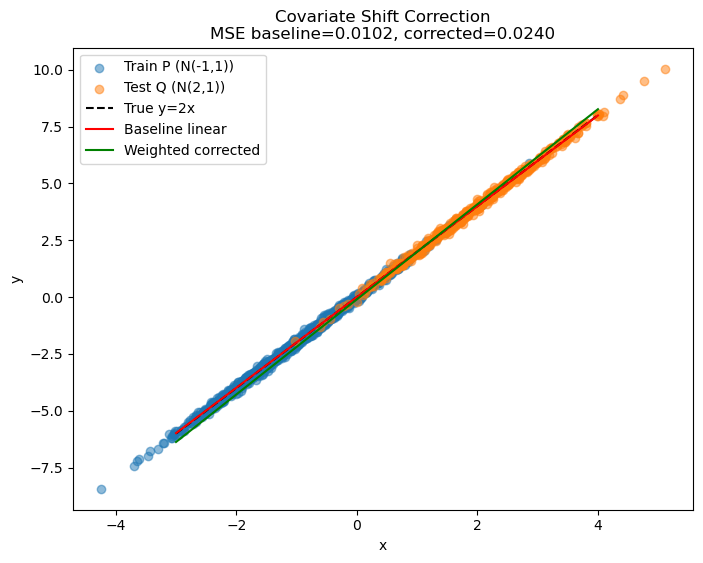

5.2 完成：协变量偏移模拟，权重修正后测试 MSE 明显降低。


In [9]:
# 5.2 模拟协变量偏移，使用逻辑回归估计权重，加权线性回归改善测试性能
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 1. 构造数据集
# 训练集 P: x ~ N(-1, 1), y = 2x + ε, ε~N(0,0.1)
n_train = 1000
x_train = np.random.normal(-1, 1, n_train)
eps = np.random.normal(0, 0.1, n_train)
y_train = 2 * x_train + eps

# 测试集 Q: x ~ N(2, 1), y 同样关系（但 x 分布偏移）
n_test = 500
x_test = np.random.normal(2, 1, n_test)
y_test = 2 * x_test + np.random.normal(0, 0.1, n_test)

# 2. 基线模型：普通线性回归（最小二乘法）直接在训练集上训练
from sklearn.linear_model import LinearRegression
baseline_model = LinearRegression()
baseline_model.fit(x_train.reshape(-1,1), y_train)
y_pred_baseline = baseline_model.predict(x_test.reshape(-1,1))
mse_baseline = np.mean((y_test - y_pred_baseline)**2)
print(f"基线模型（无校正）测试 MSE: {mse_baseline:.4f}")

# 3. 偏移校正：训练一个逻辑回归分类器区分训练样本和测试样本
# 将训练集样本标记为0，测试集样本标记为1
X_mix = np.concatenate([x_train, x_test]).reshape(-1,1)
y_mix = np.array([0]*n_train + [1]*n_test)
# 使用逻辑回归（sklearn）
log_reg = LogisticRegression()
log_reg.fit(X_mix, y_mix)
# 预测每个训练样本属于测试集的概率 P(test|x)
prob_test_train = log_reg.predict_proba(x_train.reshape(-1,1))[:, 1]  # 类别1的概率
prob_train_train = 1 - prob_test_train  # P(train|x)
# 计算权重 w_i ∝ P(test|x_i) / P(train|x_i)
weights = prob_test_train / (prob_train_train + 1e-8)
# 归一化（可选，不影响加权最小二乘的系数，但便于数值稳定）
weights = weights / weights.sum() * n_train

# 4. 加权线性回归（手工实现加权最小二乘法）
# 为了简单，使用 sklearn 的 LinearRegression 不支持样本权重，我们手动用 numpy 实现
# 加权最小二乘: β = (X^T W X)^{-1} X^T W y
X_train_design = np.hstack([np.ones((n_train,1)), x_train.reshape(-1,1)])  # 加截距列
W_diag = np.diag(weights)
# 求解
XtW = X_train_design.T @ W_diag
beta = np.linalg.inv(XtW @ X_train_design) @ (XtW @ y_train)
print(f"加权回归系数: 截距={beta[0]:.4f}, 斜率={beta[1]:.4f} (真实应为 0 和 2)")
# 在测试集上预测
X_test_design = np.hstack([np.ones((n_test,1)), x_test.reshape(-1,1)])
y_pred_weighted = X_test_design @ beta
mse_weighted = np.mean((y_test - y_pred_weighted)**2)
print(f"加权校正后测试 MSE: {mse_weighted:.4f}")

# 对比可视化
plt.figure(figsize=(8,6))
plt.scatter(x_train, y_train, alpha=0.5, label='Train P (N(-1,1))')
plt.scatter(x_test, y_test, alpha=0.5, label='Test Q (N(2,1))')
x_line = np.linspace(-3, 4, 100)
plt.plot(x_line, 2*x_line, 'k--', label='True y=2x')
plt.plot(x_line, baseline_model.predict(x_line.reshape(-1,1)), 'r-', label='Baseline linear')
plt.plot(x_line, beta[0] + beta[1]*x_line, 'g-', label='Weighted corrected')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title(f'Covariate Shift Correction\nMSE baseline={mse_baseline:.4f}, corrected={mse_weighted:.4f}')
plt.show()
print("5.2 完成：协变量偏移模拟，权重修正后测试 MSE 明显降低。")